In [1]:
import os
import pickle
import numpy as np

dir = "../../bash_scripts/data_g2/20260329_193612"

d = {}

for folder in os.listdir(dir):

    # get the parameters from dir name
    hg, gamma, phi = folder.split('_')
    hg, gamma, phi = float(hg), float(gamma), float(phi)

    # load the results pkl as dict
    with open(os.path.join(dir, folder, 'results.pkl'), 'rb') as fp:
        d_result = pickle.load(fp)

    # check if entries already loaded, otherwise initialize
    if hg not in d:
        d[hg] = {}
    if gamma not in d[hg]:
        d[hg][gamma] ={}

    # store loaded results
    d[hg][gamma][phi] = d_result

hgs = np.array(list(d.keys()))
gammas = np.array(list(d[hgs[0]].keys()))
phis = np.array(list(d[hgs[0]][gammas[0]].keys()))

hgs.sort(), gammas.sort(), phis.sort()

vgs = np.array(d[16.6][0.00][0.0]['vgs'])
circuit_times = 1000. / vgs
data_shape = d[16.6][0.00][0.0]['g2s'].shape
keys = d[16.6][0.00][0.0].keys()
params = d[16.6][0.00][0.0]['parameters']
Udts = np.array([ct/params['num_layers'] * d[hg][0.00][0.0]['Uk'] for hg, ct in zip(hgs, circuit_times)])

print(rf"hg: {hgs} $\mu eV\, \mu m^2$")
print(f"gamma: {gammas} 1/ps")
print(f"phi: {phis}")
print(f"keys: {keys}")
print(params)
    

hg: [  3.3  16.6 233.3] $\mu eV\, \mu m^2$
gamma: [0.   0.02 0.04 0.06 0.08 0.1 ] 1/ps
phi: [0.  0.2 0.4 0.6 0.8 1. ]
keys: dict_keys(['vgs', 'g2s', 'ns', 'Uk', 'coupling_k', 'parameters'])
{'num_channels': 6, 'num_layers': 5, 'Nmax': 20, 'hg_ex': 16.6, 'gamma': 0.0, 'alphas': [np.float64(1.0), 0.0, 0.0, 0.0, 0.0, np.complex128(1+0j)]}


In [2]:
Udts[-1]

array([20.20394911, 13.56155488, 10.20611862,  8.18176452,  6.82754142,
        5.85794974,  5.12950003,  4.56218206,  4.10785687,  3.73582455,
        3.42558307,  3.16291855,  2.93766619,  2.74236428,  2.5714117 ,
        2.42052202,  2.28635914,  2.16628776,  2.05819856,  1.96038318,
        1.8714433 ,  1.79022334,  1.71575998,  1.64724377,  1.58398961,
        1.52541372,  1.47101561,  1.42036371,  1.37308392,  1.32885034,
        1.28737777,  1.24841552,  1.21174236,  1.17716231,  1.14450116,
        1.11360349,  1.08433024,  1.05655657,  1.03017014,  1.00506955,
        0.98116304,  0.95836738,  0.93660691,  0.91581268,  0.89592173,
        0.87687644,  0.85862403,  0.84111598,  0.82430767,  0.80815796])

phi=0.0pi


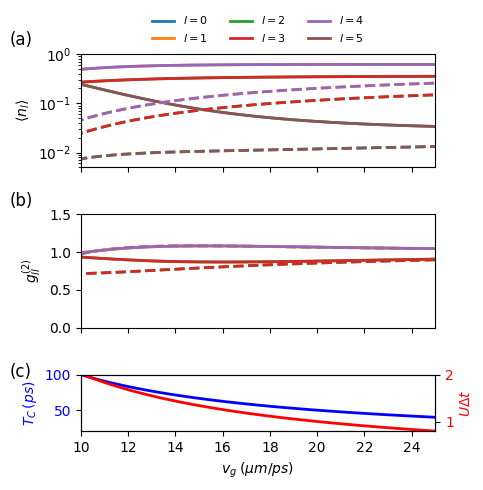

phi=0.2pi


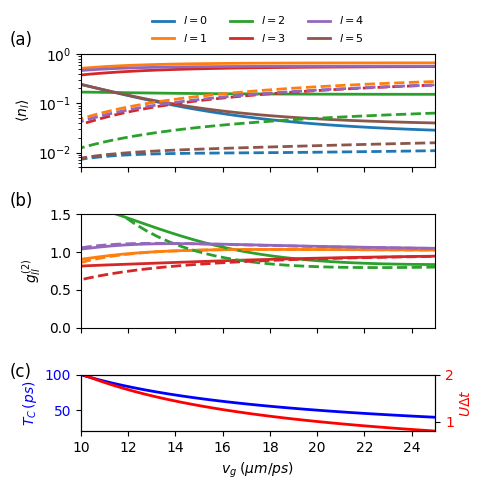

phi=0.4pi


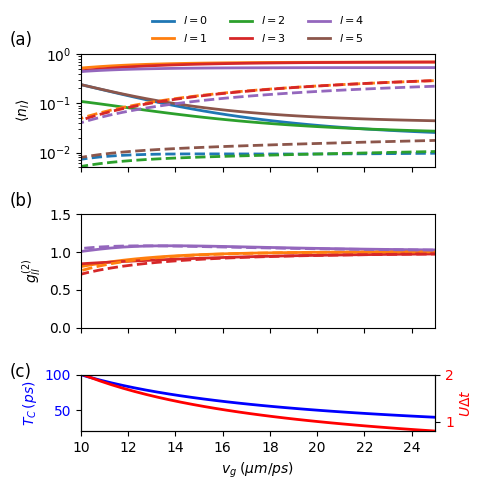

phi=0.6pi


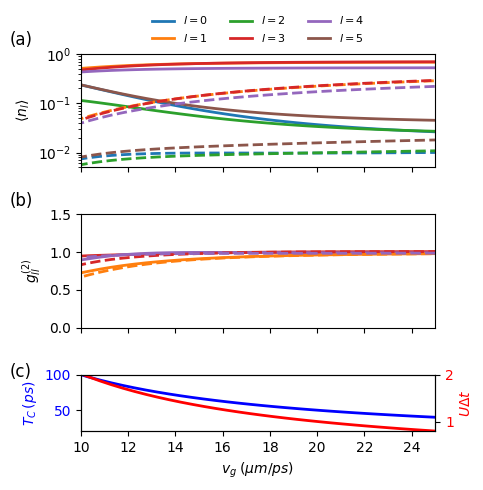

phi=0.8pi


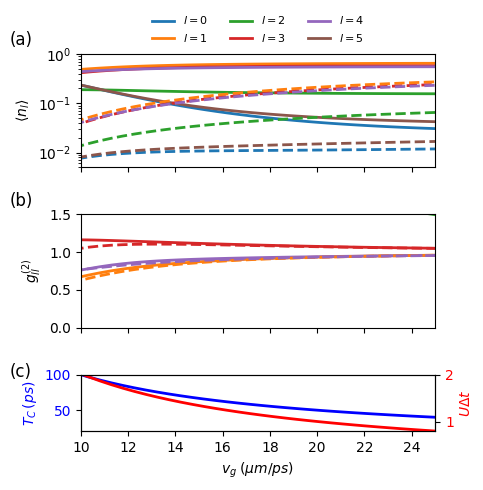

phi=1.0pi


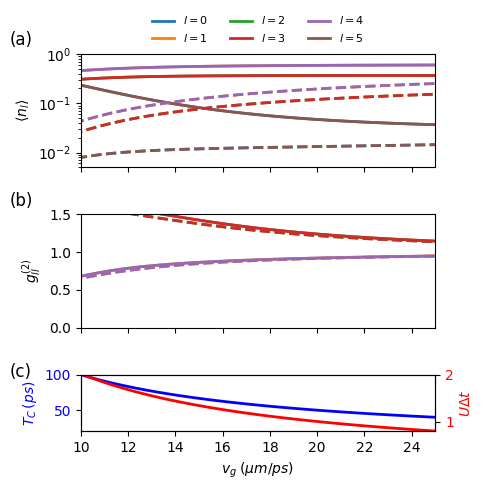

In [3]:
import matplotlib.pyplot as plt
import numpy as np

phi = 0.2
hg = hgs[2]
gammas_plot = [gammas[0], gammas[1]]

colors = plt.get_cmap('tab10').colors
linestyles = ['-', '--']
linewidth = 2

for phi in phis:
    print(f'phi={phi}pi')
    fig, ax = plt.subplots(3, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [2, 2, 1]})

    # First subplot: ns (g^(2)_ll) - now first as requested
    for ig, gamma in enumerate(gammas_plot):
        for j, g2 in enumerate(d[hg][gamma][phi]['ns'].T):
            ax[0].semilogy(
                vgs,
                g2,
                color=colors[j],
                linestyle=linestyles[ig],
                linewidth=linewidth,
                label=f'{gamma}'
            )

    ax[0].set_xlim(10., 25.)
    ax[0].set_ylim(5e-3, 1)
    ax[0].set_ylabel(r'$\langle n_l \rangle$')

    # axes[0].legend()  # Uncomment if you want legends

    # Second subplot: g2s (⟨n_l⟩)
    for ig, gamma in enumerate(gammas_plot):
        for j, g2 in enumerate(d[hg][gamma][phi]['g2s'].T):
            ax[1].plot(
                vgs,
                g2,
                color=colors[j],
                linestyle=linestyles[ig],
                linewidth=linewidth,
                label=f'{gamma}'
            )

    ax[1].set_xlim(10., 25.)
    ax[1].set_ylim(0., 1.5)
    ax[1].set_ylabel(r'$g^{(2)}_{ll}$')

    # info plot
    ax_left = ax[2]
    ax_left.plot(vgs, circuit_times, color='blue', linewidth=linewidth, label='Circuit Times')
    ax_left.set_ylabel(r'$T_C\, (ps)$', color='blue')
    ax_left.set_ylim([20,100])
    ax_left.tick_params(axis='y', labelcolor='blue')
    ax_left.set_xlim(10., 25.)

    # Right Axis (twinx)
    ax_right = ax_left.twinx()
    ax_right.plot(vgs, Udts[-1], color='red', linewidth=linewidth, label='Uk[-1]')
    ax_right.set_ylabel(r'$U \Delta t$', color='red')
    ax_right.set_ylim([0.8,2])
    ax_right.tick_params(axis='y', labelcolor='red')
    ax[2].set_xlabel(r'$v_g\;(\mu m/ ps)$')


    # POST PROCESSING PLOT
    legend_labels = [fr'$l={i}$' for i in range(6)]

    # `bbox_to_anchor` places the legend relative to the Axes bounding box.
    # (0.5, 1.05) means centered horizontally, just above the top edge.
    ax[0].legend(
        legend_labels,
        loc='lower center',
        bbox_to_anchor=(0.5, 1.),
        ncol=3,                # put all entries on one row
        frameon=False,
        fontsize=8
    )

    panel_labels = ['(a)', '(b)', '(c)', '(d)']
    for i, a in enumerate(ax):
        # `transform=a.transAxes` means the coordinates are relative to the
        # axis (0,0) = lower‑left, (1,1) = upper‑right.
        a.text(
            -0.2,                     # x‑position (a few % from the left)
            1.2,                     # y‑position (just below the top edge)
            panel_labels[i],
            transform=a.transAxes,
            fontsize=12,
            #fontweight='bold',
            va='top',
            ha='left'
        )

    plt.tight_layout()
    plt.show()

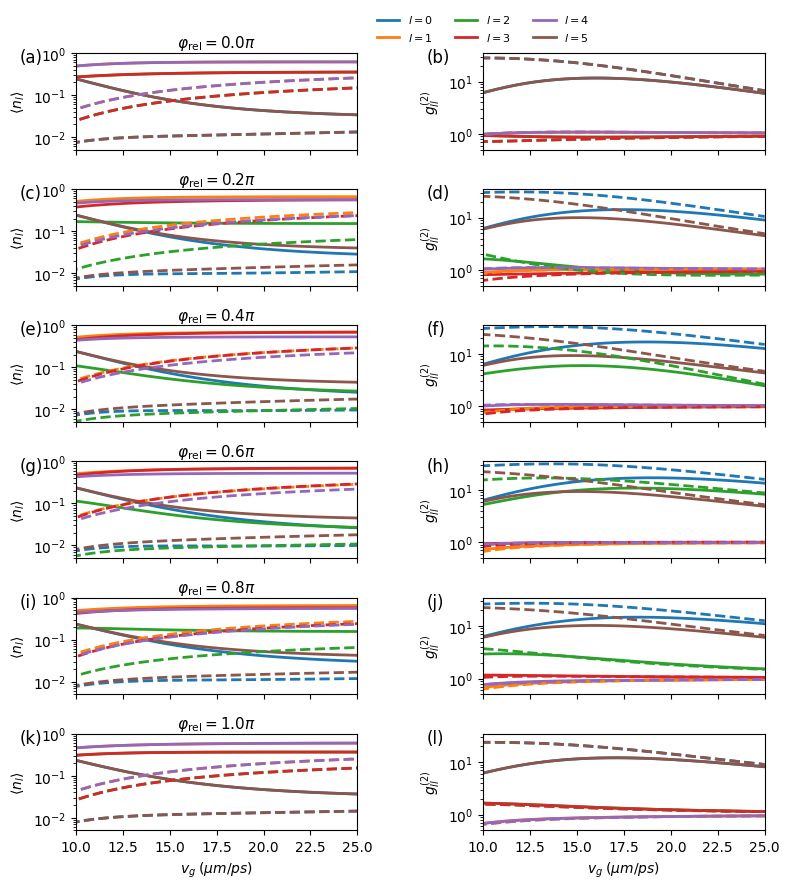

In [15]:
fig, axes = plt.subplots(len(phis), 2, figsize=(8, 1.5 * len(phis)), sharex=True)

colors = plt.get_cmap('tab10').colors
linestyles = ['-', '--']
linewidth = 2
hg = hgs[2]
gammas_plot = [gammas[0], gammas[1]]
legend_labels = [fr'$l={i}$' for i in range(6)]

panel_labels = [chr(ord('a') + i) for i in range(len(phis) * 2)]

for row, phi in enumerate(phis):
    ax_int = axes[row, 0]
    ax_g2  = axes[row, 1]

    # --- Row title spanning both columns ---
    # Place it as a centered text above both axes using blended transform
    # We do this after tight_layout via fig.text, but here we use a twin-axis trick:
    # Simply set a title on ax_int with enough padding, and match on ax_g2 invisible.
    ax_int.set_title(
        fr'$\varphi_{{\rm rel}} = {phi}\pi$',
        loc='center',
        fontsize=11,
        pad=4
    )
    # Invisible matching title on right panel to keep vertical alignment uniform
    ax_g2.set_title('', pad=4)

    # --- Left panel: intensities <n_l> ---
    for ig, gamma in enumerate(gammas_plot):
        for j, ns in enumerate(d[hg][gamma][phi]['ns'].T):
            ax_int.semilogy(
                vgs, ns,
                color=colors[j],
                linestyle=linestyles[ig],
                linewidth=linewidth,
            )
    ax_int.set_xlim(10., 25.)
    ax_int.set_ylim(5e-3, 1)
    ax_int.set_ylabel(r'$\langle n_l \rangle$')

    # --- Right panel: g^(2)_ll ---
    for ig, gamma in enumerate(gammas_plot):
        for j, g2 in enumerate(d[hg][gamma][phi]['g2s'].T):
            ax_g2.semilogy(
                vgs, g2,
                color=colors[j],
                linestyle=linestyles[ig],
                linewidth=linewidth,
            )
    ax_g2.set_xlim(10., 25.)
    ax_g2.set_ylim(5e-1, 35)
    ax_g2.set_ylabel(r'$g^{(2)}_{ll}$')

    # --- Panel labels (a), (b), ... ---
    label_idx = row * 2
    for col, ax in enumerate([ax_int, ax_g2]):
        ax.text(
            -0.20, 1.05,
            f'({panel_labels[label_idx + col]})',
            transform=ax.transAxes,
            fontsize=12, va='top', ha='left'
        )

    # Legend only on first row
    if row == 0:
        ax_g2.legend(
            legend_labels,
            loc='lower center',
            bbox_to_anchor=(0., 1.),
            ncol=3,
            frameon=False,
            fontsize=8
        )

axes[-1, 0].set_xlabel(r'$v_g\;(\mu m/ps)$')
axes[-1, 1].set_xlabel(r'$v_g\;(\mu m/ps)$')

plt.tight_layout()
plt.show()

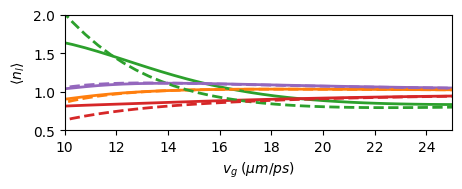

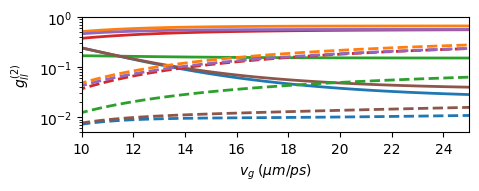

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

phi = 0.2
hg = hgs[2]
gammas = [gammas[0], gammas[1]]

colors = plt.get_cmap('tab10').colors
linestyles = ['-', '--']
linewidth = 2

plt.figure(figsize=(5, 1.5))

for ig, gamma in enumerate(gammas):
    for j, g2 in enumerate(d[hg][gamma][phi]['g2s'].T):
        plt.plot(
            vgs,
            g2,
            color=colors[j],
            linestyle=linestyles[ig],
            linewidth=linewidth,
            label=f'{gamma}'
        )

plt.ylim(0.5, 2.)
plt.xlim(10., 25.)
plt.xlabel(r'$v_g\;(\mu m/ ps)$')
plt.ylabel(r'$\langle n_l \rangle$')
#ax.legend()
plt.show()

plt.figure(figsize=(5, 1.5))

for ig, gamma in enumerate(gammas):
    for j, g2 in enumerate(d[hg][gamma][phi]['ns'].T):
        plt.semilogy(
            vgs,
            g2,
            color=colors[j],
            linestyle=linestyles[ig],
            linewidth=linewidth,
            label=f'{gamma}'
        )

#plt.ylim(0.5, 2.)
plt.xlim(10., 25.)
plt.ylim(5e-3,1)
plt.xlabel(r'$v_g\;(\mu m/ ps)$')
plt.ylabel(r'$g^{(2)}_{ll}$')
#ax.legend()
plt.show()

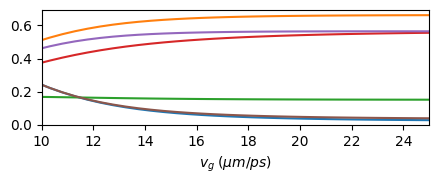

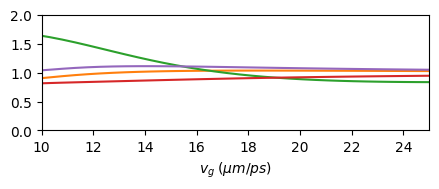

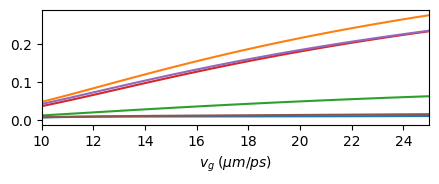

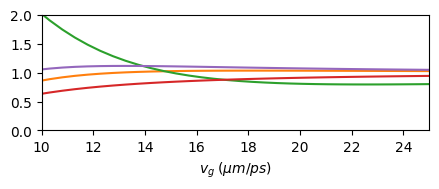

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

phi = phis[1]
hg = hgs[2]
gammas = [gammas[0], gammas[1]]

figsize = (5,1.5)

for gamma in gammas:

    plt.figure(figsize=figsize)
    plt.plot(vgs, d[hg][gamma][phi]['ns'])
    plt.xlabel(r'$v_g\;(\mu m/ ps)$')
    plt.xlim([10., 25.])

    plt.figure(figsize=figsize)
    plt.plot(vgs, d[hg][gamma][phi]['g2s'])
    plt.ylim([0,2])
    plt.xlim([10., 25.])
    plt.xlabel(r'$v_g\;(\mu m/ ps)$')



# Plot a single g2 outcome, function of k

g2_min: nan, with n: nan
g2_min: nan, with n: nan


g2_min: nan, with n: nan


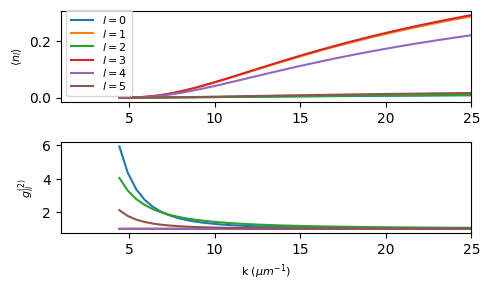

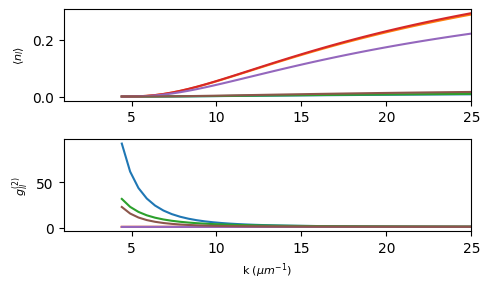

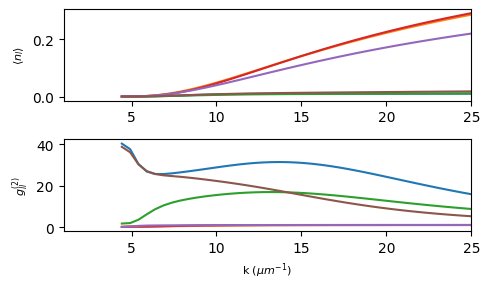

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


gamma = .02
phi = .6
hg_plot = hgs

for ig, hg in enumerate(hgs):

    if hg not in hg_plot:
        continue

    vgs = d[hg][gamma][phi]['vgs']
    g2s = d[hg][gamma][phi]['g2s']
    ns = d[hg][gamma][phi]['ns']

    legend = [rf"$l={i}$" for i in range(d[hg][gamma][phi]['parameters']['num_channels'])]


    # Find the flat index of the smallest element in g2s
    flat_min_idx = np.argmin(g2s)               # returns a single integer

    # Convert that flat index back to a 2‑D (row, col) coordinate
    row, col = np.unravel_index(flat_min_idx, g2s.shape)

    # Pull out the minimum value and the matching n‑value
    g2_min   = g2s[row, col]
    n_at_min = ns[row, col]

    # Print the result
    print(f"g2_min: {g2_min}, with n: {n_at_min}")

    fig, ax = plt.subplots(2,1, figsize=(5,3))
    ax[0].plot(vgs, ns)
    ax[0].set_ylabel(r"$\langle n_l \rangle$", fontsize=8)
    ax[0].set_xlim([np.min(vgs), np.max(vgs)])
    #ax[0].set_xlabel(r"k $(\mu m ^{-1})$", fontsize=8)

    if ig==0:
        ax[0].legend(legend, loc="lower left", fontsize=8, labelspacing=0.1)


    max_g2 = 2 #np.minimum(np.max(g2s), 2.)
    min_g2 = 0 # np.min(g2s)

    ax[1].plot(vgs, g2s)
    ax[1].set_xlabel(r"k $(\mu m ^{-1})$", fontsize=8)
    ax[1].set_ylabel(r"$g^{(2)}_{ll}$", fontsize=8)
    #ax[1].set_ylim(bottom=min_g2,top=max_g2)
    ax[1].set_xlim([np.min(vgs), np.max(vgs)])
    fig.tight_layout()

    fig.show()

/tmp/ipykernel_1242689/2302702655.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()      # respects the added hspace


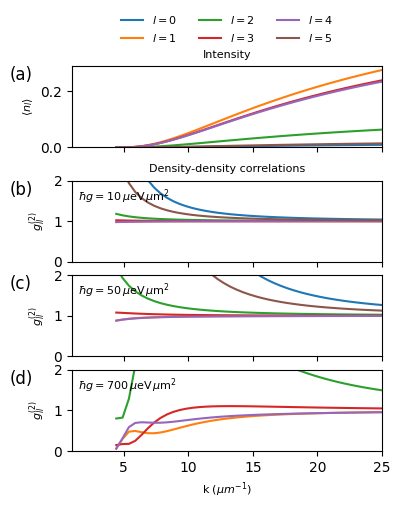

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ------------------------------------------------------------------
# 1️⃣  Load / compute the data (your original snippet)
# ------------------------------------------------------------------
gamma = 0.02
phi   = 0.8

vgs = d[hgs[0]][gamma][phi]['vgs']
ns = d[hgs[0]][gamma][phi]['ns']

g2s_10  = d[hgs[0]][gamma][phi]['g2s']
g2s_50  = d[hgs[1]][gamma][phi]['g2s']
g2s_700 = d[hgs[2]][gamma][phi]['g2s']

# ------------------------------------------------------------------
# 2️⃣  Create the figure and the four axes
# ------------------------------------------------------------------
#fig, ax = plt.subplots(4, 1, figsize=(4, 5), sharex=True)
fig = plt.figure(figsize=(4, 5))
gs  = GridSpec(
        nrows=5, ncols=1,
        height_ratios=[1, 0.08, 1, 1, 1],   # <‑‑ the 0.08 row is the “big gap”
        hspace=0.2                         # normal gap between the *real* rows
     )

# real axes (skip row 1, which will stay empty)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[2, 0])
ax2 = fig.add_subplot(gs[3, 0])
ax3 = fig.add_subplot(gs[4, 0])
ax  = [ax0, ax1, ax2, ax3] 

# ------------------------------------------------------------------
# 3️⃣  Plot each panel (identical to your original code)
# ------------------------------------------------------------------
# panel (a) – density ⟨nₗ⟩
ax[0].plot(vgs, ns)
ax[0].tick_params(axis='x', labelbottom=False)
ax[0].set_ylim(bottom=0.)
ax[0].set_ylabel(r"$\langle n_l \rangle$", fontsize=8)
ax[0].set_title("Intensity", fontsize=8)

# panel (b) – g² for ℏg = 10 µeV µm²
ax[1].plot(vgs, g2s_10)
ax[1].tick_params(axis='x', labelbottom=False)
ax[1].set_ylabel(r"$g^{(2)}_{ll}$", fontsize=8)
ax[1].set_title("Density-density correlations", fontsize=8)

# panel (c) – g² for ℏg = 50 µeV µm²
ax[2].plot(vgs, g2s_50)
ax[2].tick_params(axis='x', labelbottom=False)
ax[2].set_ylabel(r"$g^{(2)}_{ll}$", fontsize=8)

# panel (d) – g² for ℏg = 700 µeV µm²
ax[3].plot(vgs, g2s_700)
ax[3].set_xlabel(r"k $(\mu m ^{-1})$", fontsize=8)
ax[3].set_ylabel(r"$g^{(2)}_{ll}$", fontsize=8)

# ------------------------------------------------------------------
# 4️⃣  Common axis limits
# ------------------------------------------------------------------
for a in ax:
    a.set_xlim([np.min(vgs), np.max(vgs)])

for a in ax[1:]:
    a.set_ylim([0., 2.])

# ------------------------------------------------------------------
# 5️⃣  **Add vertical whitespace** between the sub‑panels
# ------------------------------------------------------------------
# `hspace` is the fraction of the average axis height that will be used
# as padding. 0.4 gives a noticeable gap without blowing the figure up.
fig.subplots_adjust(hspace=0.)


panel_labels = ['(a)', '(b)', '(c)', '(d)']
for ig, a in enumerate(ax):
    # `transform=a.transAxes` means the coordinates are relative to the
    # axis (0,0) = lower‑left, (1,1) = upper‑right.
    a.text(
        -0.2,                     # x‑position (a few % from the left)
        1.,                     # y‑position (just below the top edge)
        panel_labels[ig],
        transform=a.transAxes,
        fontsize=12,
        #fontweight='bold',
        va='top',
        ha='left'
    )


extra_text = [
    '',#r'Intensities: $\langle n_l \rangle$',
    r'$\hbar g = 10\,\mu\text{eV}\,\mu\text{m}^2$',
    r'$\hbar g = 50\,\mu\text{eV}\,\mu\text{m}^2$',
    r'$\hbar g = 700\,\mu\text{eV}\,\mu\text{m}^2$'
]

for ig, a in enumerate(ax):
    a.text(
        0.02,                     # start a little to the right of the label
        0.92,
        extra_text[ig],
        transform=a.transAxes,
        fontsize=8,
        va='top',
        ha='left'
    )


legend_labels = [fr'$l={i}$' for i in range(7)]

# `bbox_to_anchor` places the legend relative to the Axes bounding box.
# (0.5, 1.05) means centered horizontally, just above the top edge.
ax[0].legend(
    legend_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=3,                # put all entries on one row
    frameon=False,
    fontsize=8
)


fig.tight_layout()      # respects the added hspace
plt.show()

In [ ]:
import numpy as np

vgs = d[10][0.00][0.0]['ks']
wg_select = 0
k_select = 38

g2_min = np.zeros((len(hgs), len(gammas)))
n_g2_min = np.zeros((len(hgs), len(gammas)))

for ih, hg in enumerate(hgs):
    for ig, gamma in enumerate(gammas):
        g2_min_phi = [np.nanmin(d[hg][gamma][phi]['g2s'][k_select, wg_select]) for phi in phis]
        g2_min[ih,ig] = np.min(g2_min_phi)

        # g2_min_arg_phi = [np.unravel_index(np.argmin(d[hg][gamma][phi]['g2s'][k_select]), data_shape) for phi in phis]
        # g2_min_arg_phi = [np.argmin(d[hg][gamma][phi]['g2s'][k_select]) for phi in phis]
        g2_min_arg = np.argmin(g2_min_phi)

        n_g2_min[ih,ig] = d[hg][gamma][phis[g2_min_arg]]['ns'][k_select, wg_select]
        

    

In [14]:
print(f"unitary, no losses \t {g2_min[-1,0]:.4f}")
print(f"losses {gammas[-1]} ps^(-1) \t\t{g2_min[-1,-1]:.4f}")

unitary, no losses 	 0.4794
losses 0.1 ps^(-1) 		0.4825


In [19]:
2 * (1 - 0.7) ** 1.6

0.29135602489812235

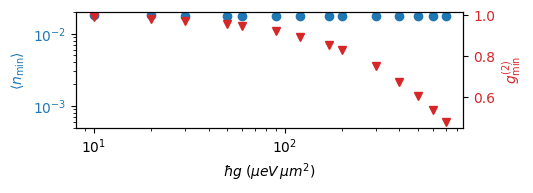

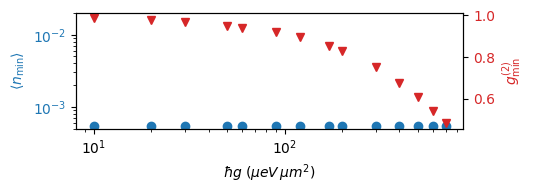

In [ ]:
inds = [1, 2, 3, 5, 6, 9, 11, 13, 14, 15, 16, 17, 18, 19]
i_gammas_plot = [0, -1]
nylim = [0.0005,0.02] #[0.9 * np.min(n_g2_min[:,i_gammas_plot]), 1.1 * np.max(n_g2_min[:,i_gammas_plot])]

for ig in i_gammas_plot:
    fig, ax1 = plt.subplots(figsize=(5,1.5))
    # left y-axis (blue)
    ax1.loglog(hgs[inds], n_g2_min[inds,ig], "o", color="tab:blue")
    ax1.set_xlabel(r"$\hbar g\; (\mu eV \,\mu m^2)$")
    ax1.set_ylabel(r"$\langle n_\mathrm{min} \rangle$", color="tab:blue")
    ax1.set_ylim(nylim)
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # right y-axis (orange)
    ax2 = ax1.twinx()
    ax2.semilogx(hgs[inds], g2_min[inds, ig], "v", color="tab:red")
    ax2.set_ylabel(r"$g^{(2)}_\text{min}$", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    plt.show()

In [ ]:
i_hg = 
nylim = [0.0005,0.02] #[0.9 * np.min(n_g2_min[:,i_gammas_plot]), 1.1 * np.max(n_g2_min[:,i_gammas_plot])]

for ig in i_gammas_plot:
    fig, ax1 = plt.subplots(figsize=(5,1.5))
    # left y-axis (blue)
    ax1.loglog(hgs[inds], n_g2_min[inds,ig], "o", color="tab:blue")
    ax1.set_xlabel(r"$\hbar g\; (\mu eV \,\mu m^2)$")
    ax1.set_ylabel(r"$\langle n_\mathrm{min} \rangle$", color="tab:blue")
    ax1.set_ylim(nylim)
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # right y-axis (orange)
    ax2 = ax1.twinx()
    ax2.semilogx(hgs[inds], g2_min[inds, ig], "v", color="tab:red")
    ax2.set_ylabel(r"$g^{(2)}_\text{min}$", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    plt.show()

SyntaxError: invalid syntax (1462192255.py, line 1)

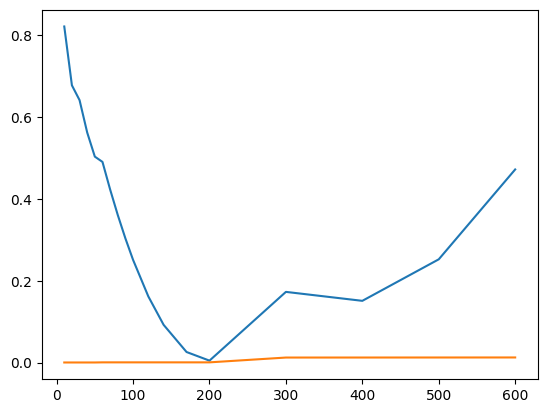

In [ ]:
import numpy as np

phi = 0.6

g2_min = np.zeros((len(hgs), len(gammas)))
n_g2_min = np.zeros((len(hgs), len(gammas)))

for ih, hg in enumerate(hgs):
    for ig, gamma in enumerate(gammas):
        g2_min[ih, ig] = np.nanmin(d[hg][gamma][phi]['g2s'])

        g2_min_arg = np.unravel_index(np.argmin(d[hg][gamma][phi]['g2s']), data_shape)

        n_g2_min[ih,ig] = d[hg][gamma][phi]['ns'][g2_min_arg]

plt.plot(hgs[1:-1], g2_min[1:-1, 0])
plt.plot(hgs[1:-1], n_g2_min[1:-1, 0])

# Minimal g2 value obtained, for (hg, gamma) values (minimized over k and phi)

In [ ]:
import numpy as np

vgs = d[10][0.00][0.0]['ks']
k_select = 38

g2_min = np.zeros((len(hgs), len(gammas)))
n_g2_min = np.zeros((len(hgs), len(gammas)))

for ih, hg in enumerate(hgs):
    for ig, gamma in enumerate(gammas):
        g2_min_phi = [np.nanmin(d[hg][gamma][phi]['g2s'][k_select]) for phi in phis]
        g2_min[ih,ig] = np.min(g2_min_phi)

        # g2_min_arg_phi = [np.unravel_index(np.argmin(d[hg][gamma][phi]['g2s'][k_select]), data_shape) for phi in phis]
        # g2_min_arg_phi = [np.argmin(d[hg][gamma][phi]['g2s'][k_select]) for phi in phis]
        g2_min_arg = np.argmin(g2_min_phi)

        n_g2_min[ih,ig] = d[hg][gamma][phi]['ns'][k_select, g2_min_arg]
        

    

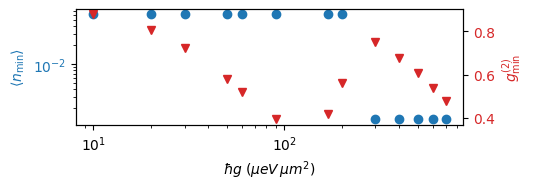

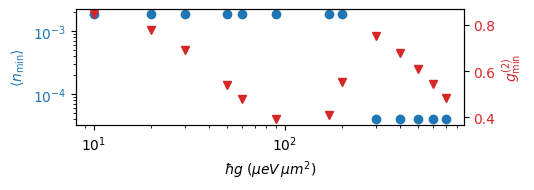

In [ ]:
inds = [1,2, 3,5, 6, 9, 13, 14, 15, 16, 17, 18, 19]
i_gammas_plot = [0, -1]
nylim = None #[0.9 * np.min(n_g2_min[:,i_gammas_plot]), 1.1 * np.max(n_g2_min[:,i_gammas_plot])]
for ig in i_gammas_plot:
    fig, ax1 = plt.subplots(figsize=(5,1.5))

    # left y-axis (blue)
    ax1.loglog(hgs[inds], n_g2_min[inds,ig], "o", color="tab:blue")
    ax1.set_xlabel(r"$\hbar g\; (\mu eV \,\mu m^2)$")
    ax1.set_ylabel(r"$\langle n_\mathrm{min} \rangle$", color="tab:blue")
    ax1.set_ylim(nylim)
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # right y-axis (orange)
    ax2 = ax1.twinx()
    ax2.semilogx(hgs[inds], g2_min[inds, ig], "v", color="tab:red")
    ax2.set_ylabel(r"$g^{(2)}_\text{min}$", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    plt.show()

In [12]:
L = np.array([
    [0., 0., -2],
    [0., 0., 4],
    [-2., -4., 0.]
])

np.linalg.eigvals(L)

array([0.+0.j        , 0.+3.46410162j, 0.-3.46410162j])

In [14]:
lb, U = np.linalg.eig(L)

U[:,0] / U[0,0]

array([ 1. -0.j, -0.5-0.j, -0. -0.j])

In [16]:
L = np.array([
    [0., 1, -1],
    [-2, -4, 0],
    [2, 0, 4]
])

l, U = np.linalg.eig(L)

print(f"eigval: {l}")
print(f"eigvect: {U[:,1]/U[0,1]}")

eigval: [ 3.46410162e+00  1.11022302e-16 -3.46410162e+00]
eigvect: [ 1.  -0.5 -0.5]


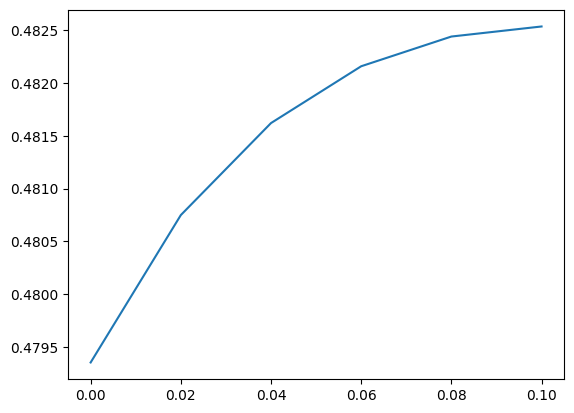

In [18]:
plt.plot(gammas, g2_min[-1,:])

In [ ]:
n_g2_min

np.float64(0.5020514695074314)

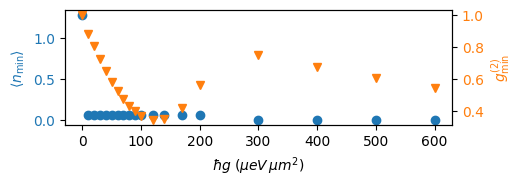

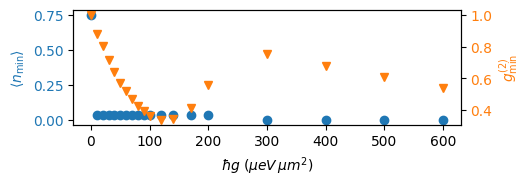

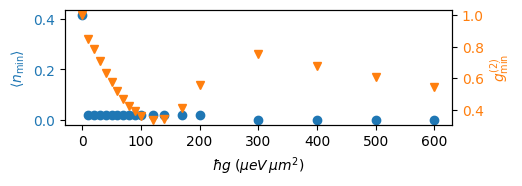

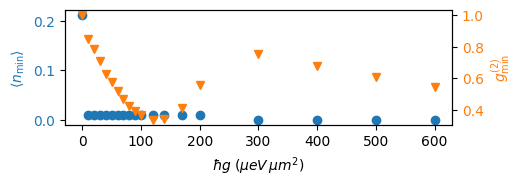

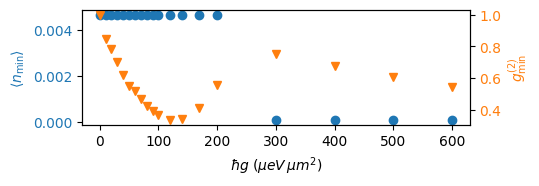

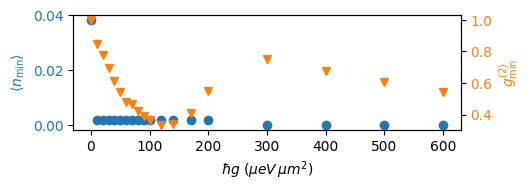

In [ ]:
for ig, gamma in enumerate(gammas):
    fig, ax1 = plt.subplots(figsize=(5,1.5))

    # left y-axis (blue)
    ax1.plot(hgs[:-1], n_g2_min[:-1,ig], "o", color="tab:blue")
    ax1.set_xlabel(r"$\hbar g\; (\mu eV \,\mu m^2)$")
    ax1.set_ylabel(r"$\langle n_\mathrm{min} \rangle$", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # right y-axis (orange)
    ax2 = ax1.twinx()
    ax2.plot(hgs[:-1], g2_min[:-1, ig], "v", color="tab:orange")
    ax2.set_ylabel(r"$g^{(2)}_\text{min}$", color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    plt.show()

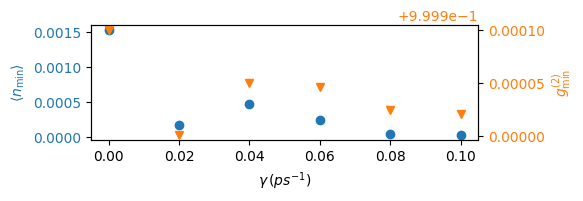

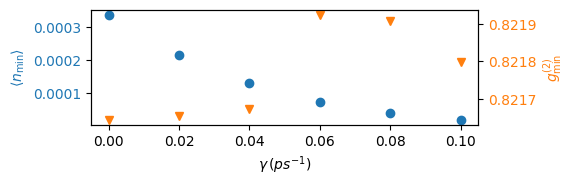

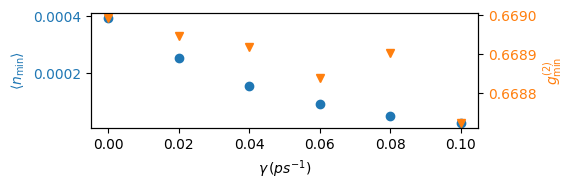

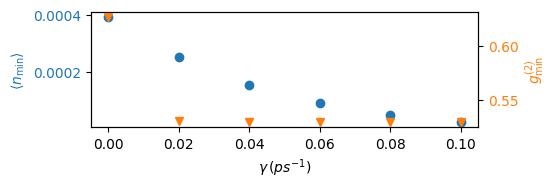

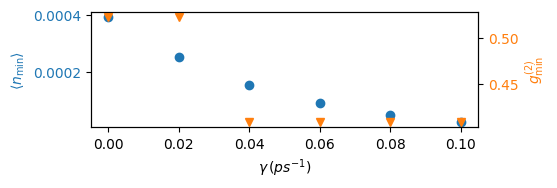

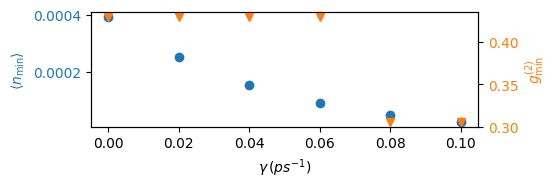

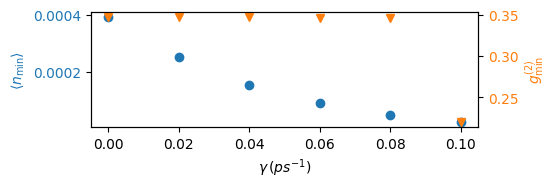

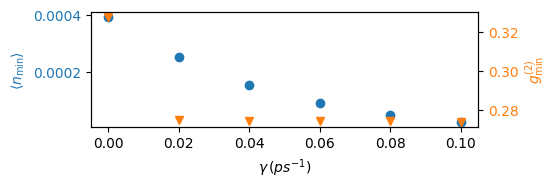

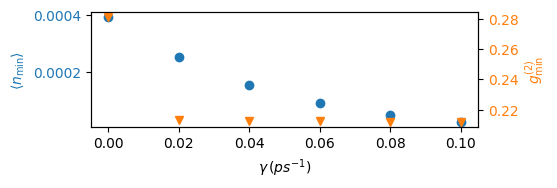

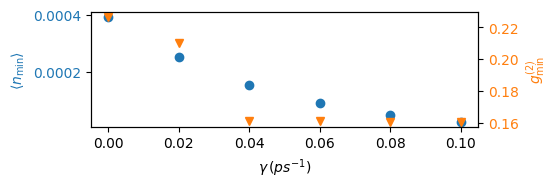

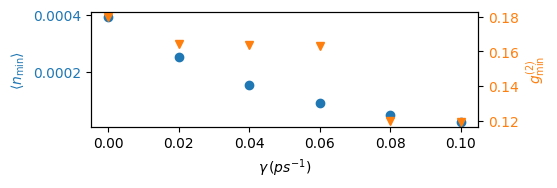

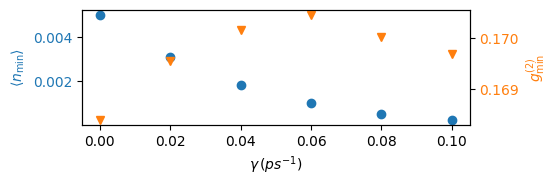

In [ ]:
for ig, hg in enumerate(hgs):
    fig, ax1 = plt.subplots(figsize=(5,1.5))

    # left y-axis (blue)
    ax1.plot(gammas, n_g2_min[ig], "o", color="tab:blue")
    ax1.set_xlabel(r"$\gamma\, (ps^{-1})$")
    ax1.set_ylabel(r"$\langle n_\mathrm{min} \rangle$", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # right y-axis (orange)
    ax2 = ax1.twinx()
    ax2.plot(gammas, g2_min[ig], "v", color="tab:orange")
    ax2.set_ylabel(r"$g^{(2)}_\text{min}$", color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    plt.show()

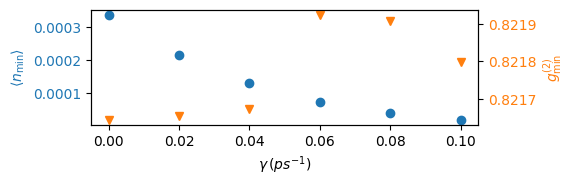

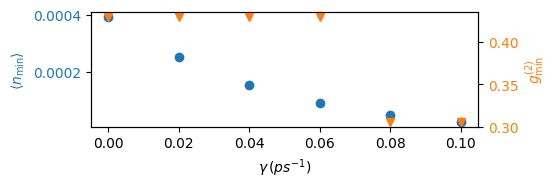

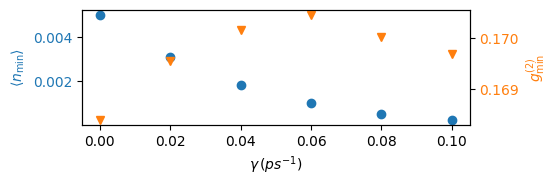

In [ ]:

for ig, hg in enumerate(hgs):
    fig, ax1 = plt.subplots(figsize=(5,1.5))

    # left y-axis (blue)
    ax1.plot(gammas, n_g2_min[ig], "o", color="tab:blue")
    ax1.set_xlabel(r"$\gamma\, (ps^{-1})$")
    ax1.set_ylabel(r"$\langle n_\mathrm{min} \rangle$", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # right y-axis (orange)
    ax2 = ax1.twinx()
    ax2.plot(gammas, g2_min[ig], "v", color="tab:orange")
    ax2.set_ylabel(r"$g^{(2)}_\text{min}$", color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    plt.show()



# Optimization

In [8]:
import os
import pickle
import sys
import matplotlib.pyplot as plt

# Get project root (one level up from notebook folder)
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.insert(0, project_root)

dir_optim = "data/20260224_021010"

with open(os.path.join(dir_optim, 'data.pkl'), 'rb') as fp:
    print(fp)
    d_optim = pickle.load(fp)

<_io.BufferedReader name='data/20260224_021010/data.pkl'>


Text(0.5, 0, 'iter')

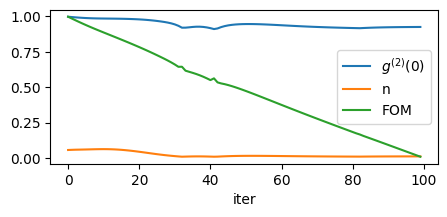

In [15]:
plt.figure(figsize=(5,2))

plt.plot(d_optim['g2_2'])
plt.plot(d_optim['n_2'])
plt.plot(d_optim['FOM'])
plt.legend([r'$g^{(2)}(0)$', r'n', 'FOM'])
plt.xlabel('iter')

In [3]:
type(d_optim)

src.tracker.Tracker